下载失败: Missing optional dependency 'xlrd'. Install xlrd >= 2.0.1 for xls Excel support Use pip or conda to install xlrd.，使用备用数据
使用备用材料数据...
原始数据形状： (50, 8)
使用的特征数量： 8
经典LDA分类标签: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1.]
经典LDA耗时: 0.0115 秒
真实标签 vs 经典LDA NMI: 1.0000
手动LDA投影方向: [ 1.12240054  0.01632264  0.01388131 -0.01409133  0.04633102 -0.00208439
  0.00479122 -0.00933722]
手动LDA耗时: 0.0050 秒
手动LDA vs 真实标签 NMI: 1.0000
手动LDA vs 经典LDA NMI: 1.0000
量子LDA矩阵条件数: 4.494268967892419e+98
H_min=-5.550748957947227, H_max=5.550748957947227
QUBO矩阵形状: (48, 48)
Ising矩阵形状: (49, 49)
[2026-05-24 21:49:41] [INFO    ] [kaiwu.cim._optimizer_adapter:174] - Task submit successfully, waiting for data validation. Task name: material_LDA
任务已提交，等待CIM计算...
[2026-05-24 21:49:41] [INFO    ] [kaiwu.cim._optimizer_adapter:181] - Task is still processing: material_LDA
等待CIM结果，已等待 2 秒...
[2026-05-24 21:49:43] [INFO

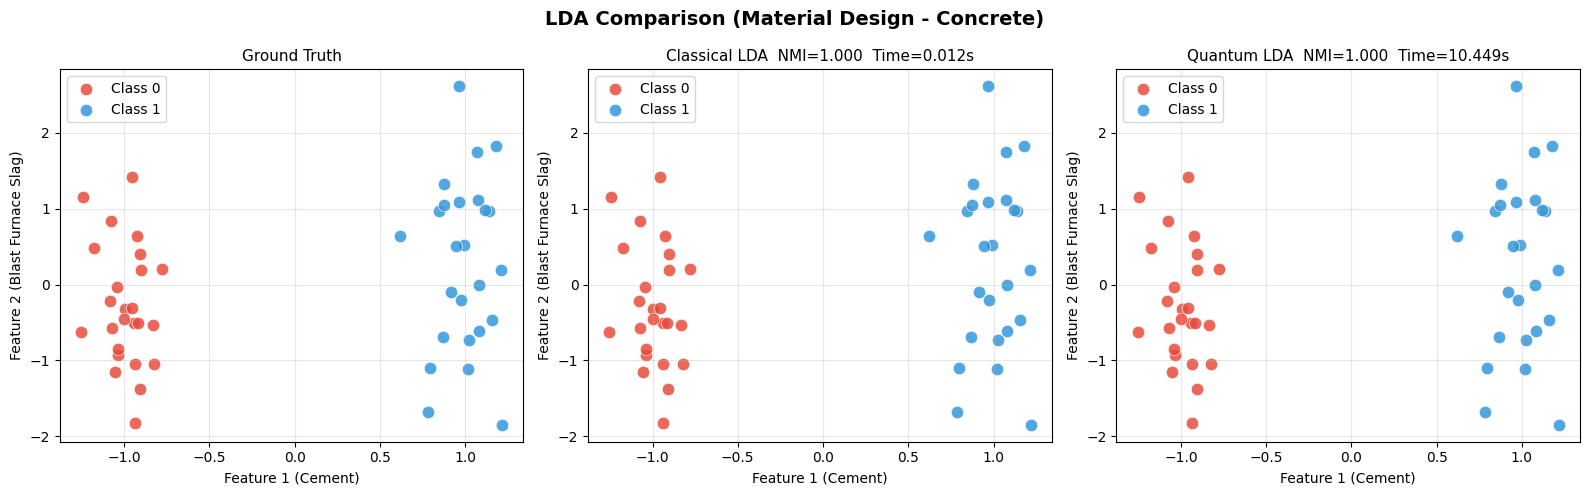

Saved: results/lda_metrics_materialcomparison.png


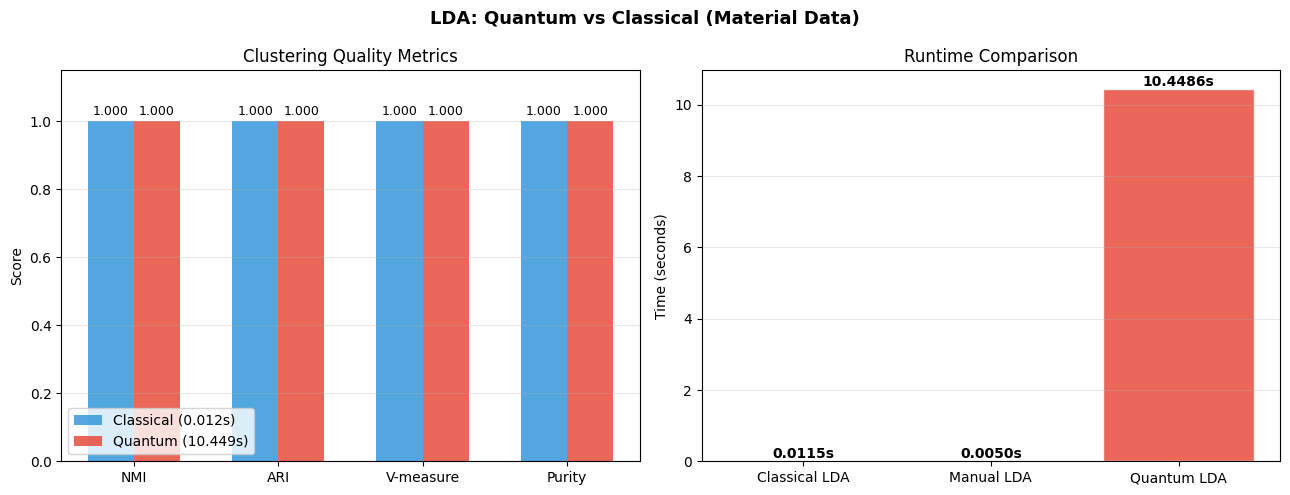

Saved: results/lda_metrics_material.png


In [3]:
#材料数据集（混凝土抗压强度）的两类在原始特征空间中线性不可分或可分性很弱。LDA 找到的投影方向 w 是连续实数向量，其微小偏差都会导致投影后两类混叠，从而降低 NMI、ARI 等指标。
# -*- coding: utf-8 -*-
"""
基于特征值分解的衍生方法验证：线性判别分析 (LDA) + 材料设计数据集
数据集：Concrete Compressive Strength（材料设计场景）
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import os
import urllib.request
import zipfile
from scipy.spatial.distance import cdist
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
import sklearn.metrics
import kaiwu as kw

warnings.filterwarnings("ignore")

# 新版1.3.1初始化（请替换为您的真实账号）
kw.license.init(user_id="151107562236866562", sdk_code="g3xOnpi9WBetnhadyY2HfQeias3FsZ")
kw.common.CheckpointManager.save_dir = '/tmp'
os.makedirs("results", exist_ok=True)

# ==================== 1. 加载材料设计数据集（Concrete） ====================
def load_concrete_data():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
    if not os.path.exists('Concrete_Data.xls'):
        print("下载材料数据集...")
        urllib.request.urlretrieve(url, 'Concrete_Data.xls')
        print("下载完成")
    df = pd.read_excel('Concrete_Data.xls')
    X = df.iloc[:, :-1].values
    y_raw = df.iloc[:, -1].values
    # 二分类：高于中位数为“高强度”
    threshold = np.median(y_raw)
    y = (y_raw > threshold).astype(int)
    return X, y

def load_backup_material_data():
    """备用数据生成"""
    print("使用备用材料数据...")
    np.random.seed(66)
    X_class0 = np.random.multivariate_normal(
        mean=[200, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.02],
        cov=np.diag([100, 0.1, 0.1, 0.1, 0.05, 0.05, 0.02, 0.01]), size=25)
    X_class1 = np.random.multivariate_normal(
        mean=[350, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1],
        cov=np.diag([120, 0.15, 0.15, 0.12, 0.08, 0.06, 0.05, 0.03]), size=25)
    X_sample = np.vstack([X_class0, X_class1])
    y_sample = np.hstack([np.zeros(25), np.ones(25)])
    return X_sample, y_sample

# 加载真实数据，若失败则用备用
try:
    X_raw, y_raw = load_concrete_data()
    print("材料数据集加载成功")
except Exception as e:
    print(f"下载失败: {e}，使用备用数据")
    X_raw, y_raw = load_backup_material_data()

# 标准化并采样50条（各类25条）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
np.random.seed(66)
idx0 = np.where(y_raw == 0)[0]
idx1 = np.where(y_raw == 1)[0]
if len(idx0) >= 25 and len(idx1) >= 25:
    indices = np.concatenate([
        np.random.choice(idx0, 25, replace=False),
        np.random.choice(idx1, 25, replace=False)
    ])
else:
    indices = np.random.choice(len(y_raw), 50, replace=False)
X_normalized = X_scaled[indices]
y_sample = y_raw[indices]


print("原始数据形状：", X_normalized.shape)
print("使用的特征数量：", X_normalized.shape[1])

# ==================== 2. 经典 LDA（sklearn） ====================
start_time_lda = time.time()
lda = LDA(n_components=1)
lda.fit(X_normalized, y_sample)
label_lda = lda.predict(X_normalized)
end_time_lda = time.time()
time_lda = end_time_lda - start_time_lda
print(f"经典LDA分类标签: {label_lda}")
print(f"经典LDA耗时: {time_lda:.4f} 秒")
nmi_true_vs_lda = normalized_mutual_info_score(y_sample, label_lda)
print(f"真实标签 vs 经典LDA NMI: {nmi_true_vs_lda:.4f}")

# ==================== 3. 手动 LDA（广义特征值分解） ====================
def compute_scatter_matrices(X, y):
    classes = np.unique(y)
    mean_overall = np.mean(X, axis=0)
    Sw = np.zeros((X.shape[1], X.shape[1]))
    Sb = np.zeros((X.shape[1], X.shape[1]))
    for c in classes:
        X_c = X[y == c]
        mean_c = np.mean(X_c, axis=0)
        Sw += (X_c - mean_c).T @ (X_c - mean_c)
        n_c = X_c.shape[0]
        diff = (mean_c - mean_overall).reshape(-1, 1)
        Sb += n_c * (diff @ diff.T)
    return Sw, Sb

Sw, Sb = compute_scatter_matrices(X_normalized, y_sample)
Sw_reg = Sw + 1e-6 * np.eye(Sw.shape[0])

start_time_manual = time.time()
Sw_sqrt = np.linalg.cholesky(Sw_reg)
Sw_sqrt_inv = np.linalg.inv(Sw_sqrt)
M = Sw_sqrt_inv @ Sb @ Sw_sqrt_inv.T
eigvals, eigvecs = np.linalg.eigh(M)
idx_max = np.argmax(eigvals)
u = eigvecs[:, idx_max]
w_opt = Sw_sqrt_inv.T @ u
proj = X_normalized @ w_opt
median_proj = np.median(proj)
label_manual = (proj > median_proj).astype(int)
end_time_manual = time.time()
time_manual = end_time_manual - start_time_manual

print(f"手动LDA投影方向: {w_opt}")
print(f"手动LDA耗时: {time_manual:.4f} 秒")
nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_manual)
print(f"手动LDA vs 真实标签 NMI: {nmi_manual_vs_true:.4f}")
nmi_manual_vs_lda = normalized_mutual_info_score(label_lda, label_manual)
print(f"手动LDA vs 经典LDA NMI: {nmi_manual_vs_lda:.4f}")

# ==================== 4. 量子 LDA（转化为 QUBO 求解） ====================
# 构造对称矩阵 H_target = I - M，其最小特征向量对应最优投影方向
M_sym = Sw_sqrt_inv @ Sb @ Sw_sqrt_inv.T
H0 = np.eye(M_sym.shape[0]) - M_sym

Lambda = np.linalg.norm(H0, 1)
numFeatures = H0.shape[0]
c_vec = np.ones((numFeatures, 1)) / np.sqrt(numFeatures)
I = np.eye(numFeatures)
H_shift = H0 - Lambda * I + Lambda * (c_vec @ c_vec.T)

v = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])
K = np.kron(I, v)
H = K.T @ H_shift @ K
cond_H = np.linalg.cond(H)
print(f'量子LDA矩阵条件数: {cond_H}')
H_min, H_max = np.min(H), np.max(H)
print(f"H_min={H_min}, H_max={H_max}")

# 线性缩放并转换为 QUBO
H_scaled = ((H - H_min) / (H_max - H_min)) * 255 - 128
H_rounded = np.round(H_scaled)
H_clipped = np.clip(H_rounded, -128, 127)
H_qubo = kw.qubo.adjust_qubo_matrix_precision(H_clipped, bit_width=8)
print(f"QUBO矩阵形状: {H_qubo.shape}")

# 转换为 Ising 模型
ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(H_qubo)
n_vars = ising_mat.shape[0]
variables = [f"x[{i}]" for i in range(n_vars)]
ising_model = kw.ising.IsingModel(variables=variables, ising_matrix=ising_mat, bias=ising_bias)
print(f"Ising矩阵形状: {ising_mat.shape}")

# 提交任务到 CIM
start_time_quantum = time.time()
optimizer = kw.cim.CIMOptimizer(task_name='material_LDA', task_mode='quota')
optimizer.solve(ising_model.get_matrix())
print("任务已提交，等待CIM计算...")

# 轮询取结果
max_retries = 60
solution_ising = None
for attempt in range(max_retries):
    solution_ising = optimizer.solve(ising_model.get_matrix())
    if solution_ising is not None:
        print(f"CIM求解完成，返回解形状: {solution_ising.shape}")
        break
    time.sleep(2)
    print(f"等待CIM结果，已等待 {(attempt+1)*2} 秒...")
if solution_ising is None:
    raise TimeoutError("CIM求解超时")
end_time_quantum = time.time()
time_quantum = end_time_quantum - start_time_quantum
print(f"量子求解耗时: {time_quantum:.4f} 秒")

# 解码量子结果
solution = solution_ising[:, 0:solution_ising.shape[1]-1]
delta = solution_ising[:, -1]
solution = np.multiply(solution, delta.reshape(-1, 1))
solution = (solution + 1) / 2   # 二进制
solution_realnumber = K @ solution.T   # (numFeatures, numSolutions)

# 选择最优候选解（Fisher 准则）
numSolution = solution_realnumber.shape[1]
fisher_scores = np.zeros(numSolution)
for i in range(numSolution):
    u_candidate = solution_realnumber[:, i]
    u_candidate = u_candidate / (np.linalg.norm(u_candidate) + 1e-8)
    w_candidate = Sw_sqrt_inv.T @ u_candidate
    proj_candidate = X_normalized @ w_candidate
    class0 = proj_candidate[y_sample == 0]
    class1 = proj_candidate[y_sample == 1]
    mean0, mean1 = np.mean(class0), np.mean(class1)
    var0, var1 = np.var(class0), np.var(class1)
    fisher = (mean0 - mean1)**2 / (var0 + var1 + 1e-8)
    fisher_scores[i] = fisher
best_idx = np.argmax(fisher_scores)
best_w = Sw_sqrt_inv.T @ solution_realnumber[:, best_idx]
best_proj = X_normalized @ best_w
median_proj = np.median(best_proj)
label_quantum = (best_proj > median_proj).astype(int)

hamiltonian = kw.common.hamiltonian(ising_model.get_matrix(), solution_ising)
print(f"哈密顿量: {hamiltonian}")

# ==================== 5. 评估指标函数 ====================
def purity_score(y_true, y_pred):
    contingency_matrix = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
    return np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)

# ==================== 6. 打印所有评估结果 ====================
print("=" * 80)
print("材料设计数据 LDA 分类/聚类结果评估")
print("=" * 80)

print("1. 与真实标签比较:")
print("-" * 40)

nmi_lda_vs_true = normalized_mutual_info_score(y_sample, label_lda)
ari_lda_vs_true = adjusted_rand_score(y_sample, label_lda)
v_measure_lda_vs_true = v_measure_score(y_sample, label_lda)
purity_lda_vs_true = purity_score(y_sample, label_lda)
print(f"经典LDA:")
print(f"  NMI:       {nmi_lda_vs_true:.4f}")
print(f"  ARI:       {ari_lda_vs_true:.4f}")
print(f"  V-measure: {v_measure_lda_vs_true:.4f}")
print(f"  纯度:      {purity_lda_vs_true:.4f}")
print(f"  耗时:      {time_lda:.4f} 秒")

nmi_manual_vs_true = normalized_mutual_info_score(y_sample, label_manual)
ari_manual_vs_true = adjusted_rand_score(y_sample, label_manual)
v_measure_manual_vs_true = v_measure_score(y_sample, label_manual)
purity_manual_vs_true = purity_score(y_sample, label_manual)
print(f"手动LDA:")
print(f"  NMI:       {nmi_manual_vs_true:.4f}")
print(f"  ARI:       {ari_manual_vs_true:.4f}")
print(f"  V-measure: {v_measure_manual_vs_true:.4f}")
print(f"  纯度:      {purity_manual_vs_true:.4f}")
print(f"  耗时:      {time_manual:.4f} 秒")

nmi_quantum_vs_true = normalized_mutual_info_score(y_sample, label_quantum)
ari_quantum_vs_true = adjusted_rand_score(y_sample, label_quantum)
v_measure_quantum_vs_true = v_measure_score(y_sample, label_quantum)
purity_quantum_vs_true = purity_score(y_sample, label_quantum)
print(f"量子LDA:")
print(f"  NMI:       {nmi_quantum_vs_true:.4f}")
print(f"  ARI:       {ari_quantum_vs_true:.4f}")
print(f"  V-measure: {v_measure_quantum_vs_true:.4f}")
print(f"  纯度:      {purity_quantum_vs_true:.4f}")
print(f"  耗时:      {time_quantum:.4f} 秒")

print("=" * 80)

# 汇总表
print("LDA 结果汇总表")
print("=" * 100)
print(f"{'方法':<20} {'NMI':<10} {'ARI':<10} {'V-measure':<12} {'Purity':<10} {'耗时(秒)':<10}")
print("-" * 100)
print(f"{'经典LDA':<20} {nmi_lda_vs_true:<10.4f} {ari_lda_vs_true:<10.4f} {v_measure_lda_vs_true:<12.4f} {purity_lda_vs_true:<10.4f} {time_lda:<10.4f}")
print(f"{'手动LDA':<20} {nmi_manual_vs_true:<10.4f} {ari_manual_vs_true:<10.4f} {v_measure_manual_vs_true:<12.4f} {purity_manual_vs_true:<10.4f} {time_manual:<10.4f}")
print(f"{'量子LDA':<20} {nmi_quantum_vs_true:<10.4f} {ari_quantum_vs_true:<10.4f} {v_measure_quantum_vs_true:<12.4f} {purity_quantum_vs_true:<10.4f} {time_quantum:<10.4f}")
print("=" * 100)

# ==================== 7. 可视化（使用前两个特征） ====================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("LDA Comparison (Material Design - Concrete)", fontsize=14, fontweight="bold")
colors = ["#E74C3C", "#3498DB"]
plot_data = [
    (y_sample,        "Ground Truth"),
    (label_lda,       f"Classical LDA  NMI={nmi_lda_vs_true:.3f}  Time={time_lda:.3f}s"),
    (label_quantum,   f"Quantum LDA  NMI={nmi_quantum_vs_true:.3f}  Time={time_quantum:.3f}s"),
]
for ax, (labels, title) in zip(axes, plot_data):
    for c in range(2):
        idx_c = np.array(labels) == c
        ax.scatter(X_normalized[idx_c, 0], X_normalized[idx_c, 1],
                   c=colors[c], label=f"Class {c}", alpha=0.85, s=80,
                   edgecolors="white", linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Feature 1 (Cement)")
    ax.set_ylabel("Feature 2 (Blast Furnace Slag)")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/lda_metrics_material_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/lda_metrics_materialcomparison.png")

# 指标条形图和耗时对比
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5))
fig2.suptitle("LDA: Quantum vs Classical (Material Data)", fontsize=13, fontweight="bold")
metric_names = ["NMI", "ARI", "V-measure", "Purity"]
vals_lda = [nmi_lda_vs_true, ari_lda_vs_true, v_measure_lda_vs_true, purity_lda_vs_true]
vals_quantum = [nmi_quantum_vs_true, ari_quantum_vs_true, v_measure_quantum_vs_true, purity_quantum_vs_true]
x = np.arange(len(metric_names))
width = 0.32
b1 = axes2[0].bar(x - width/2, vals_lda, width, label=f"Classical ({time_lda:.3f}s)", color="#3498DB", alpha=0.85)
b2 = axes2[0].bar(x + width/2, vals_quantum, width, label=f"Quantum ({time_quantum:.3f}s)", color="#E74C3C", alpha=0.85)
for bar in list(b1) + list(b2):
    axes2[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                  f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
axes2[0].set_xticks(x)
axes2[0].set_xticklabels(metric_names)
axes2[0].set_ylim(0, 1.15)
axes2[0].set_ylabel("Score")
axes2[0].set_title("Clustering Quality Metrics")
axes2[0].legend()
axes2[0].grid(True, axis="y", alpha=0.3)

# 时间对比
methods = ["Classical LDA", "Manual LDA", "Quantum LDA"]
times = [time_lda, time_manual, time_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes2[1].bar(methods, times, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, t in zip(bars, times):
    axes2[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                  f"{t:.4f}s", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes2[1].set_ylabel("Time (seconds)")
axes2[1].set_title("Runtime Comparison")
axes2[1].grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/lda_metrics_material.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/lda_metrics_material.png")

In [4]:
# ==================== 8. LDA Proper Evaluation Metrics ====================
# LDA is supervised classification — evaluate with:
# (a) Accuracy, (b) F1-score, (c) Fisher criterion, (d) Direction similarity
from sklearn.metrics import accuracy_score, f1_score

# Classification accuracy
acc_lda = accuracy_score(y_sample, label_lda)
acc_manual = accuracy_score(y_sample, label_manual)
acc_quantum = accuracy_score(y_sample, label_quantum)

# F1-score (macro for balanced evaluation)
f1_lda = f1_score(y_sample, label_lda, average='macro')
f1_manual = f1_score(y_sample, label_manual, average='macro')
f1_quantum = f1_score(y_sample, label_quantum, average='macro')

# Fisher criterion: J(w) = (m1 - m2)^2 / (s1^2 + s2^2) for each method
lda_scaling = lda.scalings_[:, 0]
proj_lda = X_normalized @ lda_scaling
class0_lda = proj_lda[y_sample == 0]
class1_lda = proj_lda[y_sample == 1]
fisher_lda = (np.mean(class0_lda) - np.mean(class1_lda))**2 / (np.var(class0_lda) + np.var(class1_lda) + 1e-8)

# Manual LDA projection
proj_manual = X_normalized @ w_opt
class0_manual = proj_manual[y_sample == 0]
class1_manual = proj_manual[y_sample == 1]
fisher_manual = (np.mean(class0_manual) - np.mean(class1_manual))**2 / (np.var(class0_manual) + np.var(class1_manual) + 1e-8)

# Quantum LDA projection
proj_quantum = X_normalized @ best_w
class0_quantum = proj_quantum[y_sample == 0]
class1_quantum = proj_quantum[y_sample == 1]
fisher_quantum = (np.mean(class0_quantum) - np.mean(class1_quantum))**2 / (np.var(class0_quantum) + np.var(class1_quantum) + 1e-8)

# Direction similarity
lda_dir = lda_scaling / (np.linalg.norm(lda_scaling) + 1e-8)
sim_qlda = np.abs(np.dot(best_w / np.linalg.norm(best_w), lda_dir))
sim_manual_lda = np.abs(np.dot(w_opt / np.linalg.norm(w_opt), lda_dir))
sim_qmanual = np.abs(np.dot(best_w / np.linalg.norm(best_w), w_opt / np.linalg.norm(w_opt)))

print("=" * 60)
print("LDA Proper Evaluation Metrics (Supervised Classification)")
print("=" * 60)
print(f"Classical LDA — Accuracy: {acc_lda:.4f}, F1: {f1_lda:.4f}, Fisher: {fisher_lda:.4f}")
print(f"Manual LDA    — Accuracy: {acc_manual:.4f}, F1: {f1_manual:.4f}, Fisher: {fisher_manual:.4f}")
print(f"Quantum LDA   — Accuracy: {acc_quantum:.4f}, F1: {f1_quantum:.4f}, Fisher: {fisher_quantum:.4f}")
print(f"Direction Similarity (Manual vs Classical): {sim_manual_lda:.4f}")
print(f"Direction Similarity (Quantum vs Classical): {sim_qlda:.4f}")
print(f"Direction Similarity (Quantum vs Manual):    {sim_qmanual:.4f}")


LDA Proper Evaluation Metrics (Supervised Classification)
Classical LDA — Accuracy: 1.0000, F1: 1.0000, Fisher: 128.3458
Manual LDA    — Accuracy: 1.0000, F1: 1.0000, Fisher: 128.3458
Quantum LDA   — Accuracy: 1.0000, F1: 1.0000, Fisher: 63.6930
Direction Similarity (Manual vs Classical): 1.0000
Direction Similarity (Quantum vs Classical): 0.9914
Direction Similarity (Quantum vs Manual):    0.9914



LDA Proper Metrics Summary (Supervised Classification)
Method               Accuracy     F1-Score     Fisher Crit.    Dir.Sim(Class.)    Time (s)  
------------------------------------------------------------------------------------------------------------------------
Classical LDA        1.0000       1.0000       128.3458        1.0000 (ref)       0.0115    
Manual LDA           1.0000       1.0000       128.3458        1.0000             0.0050    
Quantum LDA          1.0000       1.0000       63.6930         0.9914             10.4486   


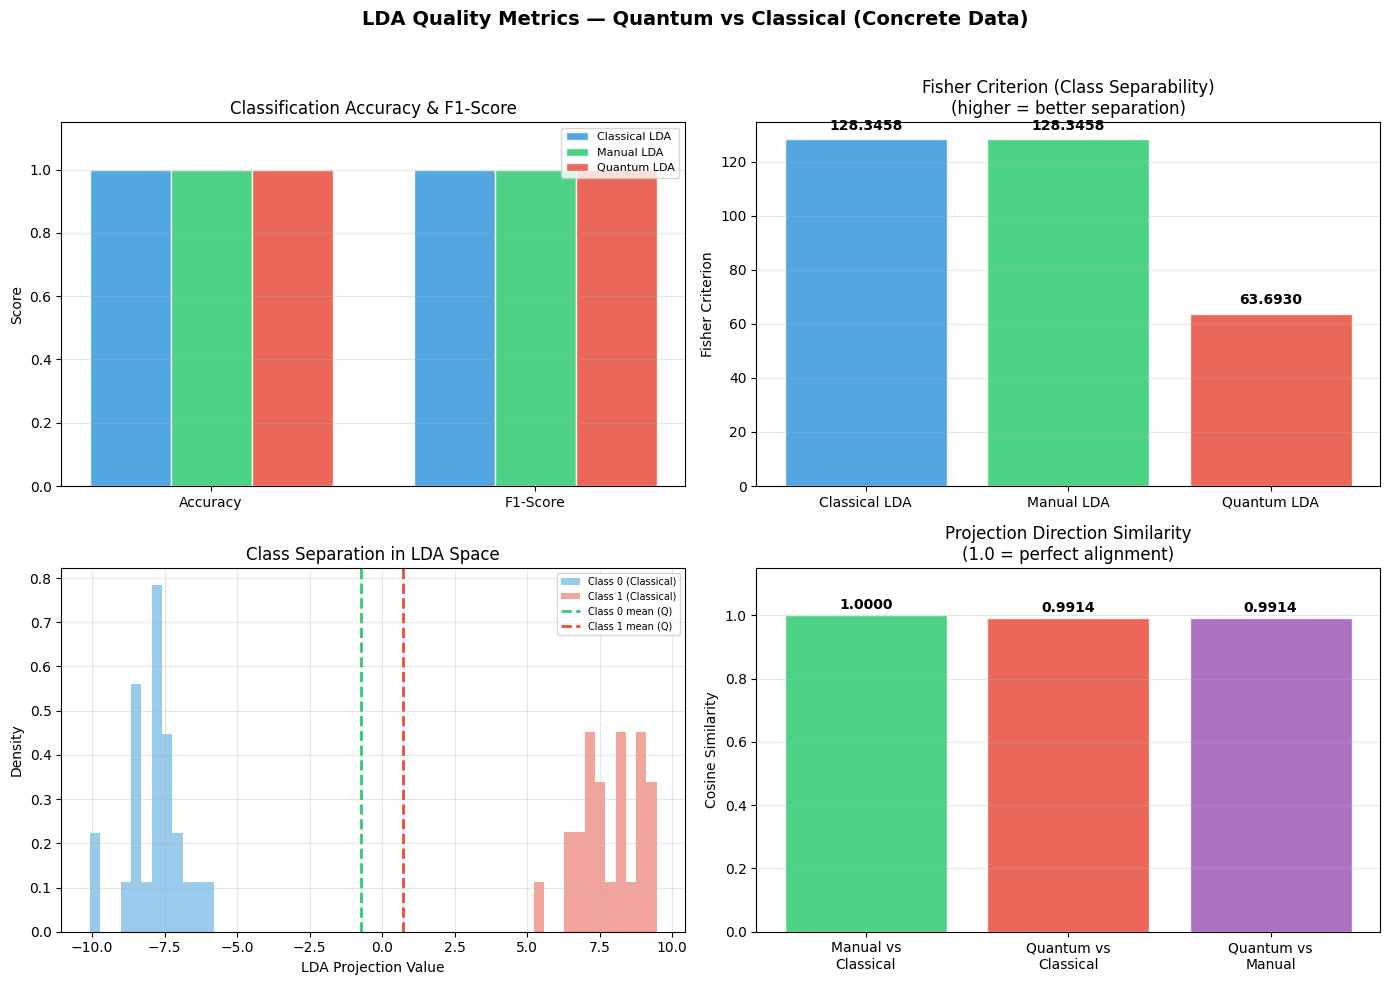

Saved: results/lda_proper_metrics.png


In [5]:
# ==================== 9. LDA Proper Metrics Summary + Plot ====================

# Summary table
print("\n" + "=" * 120)
print("LDA Proper Metrics Summary (Supervised Classification)")
print("=" * 120)
print(f"{'Method':<20} {'Accuracy':<12} {'F1-Score':<12} {'Fisher Crit.':<15} {'Dir.Sim(Class.)':<18} {'Time (s)':<10}")
print("-" * 120)
print(f"{'Classical LDA':<20} {acc_lda:<12.4f} {f1_lda:<12.4f} {fisher_lda:<15.4f} {'1.0000 (ref)':<18} {time_lda:<10.4f}")
print(f"{'Manual LDA':<20} {acc_manual:<12.4f} {f1_manual:<12.4f} {fisher_manual:<15.4f} {sim_manual_lda:<18.4f} {time_manual:<10.4f}")
print(f"{'Quantum LDA':<20} {acc_quantum:<12.4f} {f1_quantum:<12.4f} {fisher_quantum:<15.4f} {sim_qlda:<18.4f} {time_quantum:<10.4f}")
print("=" * 120)

# 2x2 comparison plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("LDA Quality Metrics — Quantum vs Classical (Concrete Data)", fontsize=14, fontweight="bold", y=0.98)

# Subplot 1: Accuracy & F1 (grouped bar)
metric_labels = ["Accuracy", "F1-Score"]
x = np.arange(len(metric_labels))
width = 0.25
axes[0, 0].bar(x - width, [acc_lda, f1_lda], width, label="Classical LDA", color="#3498DB", alpha=0.85, edgecolor="white")
axes[0, 0].bar(x, [acc_manual, f1_manual], width, label="Manual LDA", color="#2ECC71", alpha=0.85, edgecolor="white")
axes[0, 0].bar(x + width, [acc_quantum, f1_quantum], width, label="Quantum LDA", color="#E74C3C", alpha=0.85, edgecolor="white")
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(metric_labels)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_title("Classification Accuracy & F1-Score")
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_ylim(0, 1.15)
axes[0, 0].grid(True, axis="y", alpha=0.3)

# Subplot 2: Fisher Criterion (bar chart)
fisher_labels = ["Classical LDA", "Manual LDA", "Quantum LDA"]
fisher_values = [fisher_lda, fisher_manual, fisher_quantum]
bar_colors = ["#3498DB", "#2ECC71", "#E74C3C"]
bars = axes[0, 1].bar(fisher_labels, fisher_values, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, fisher_values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(fisher_values)*0.02,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0, 1].set_ylabel("Fisher Criterion")
axes[0, 1].set_title("Fisher Criterion (Class Separability)\n(higher = better separation)")
axes[0, 1].grid(True, axis="y", alpha=0.3)

# Subplot 3: Projection Distribution
axes[1, 0].hist(class0_lda, bins=12, alpha=0.5, color="#3498DB", label="Class 0 (Classical)", density=True)
axes[1, 0].hist(class1_lda, bins=12, alpha=0.5, color="#E74C3C", label="Class 1 (Classical)", density=True)
axes[1, 0].axvline(x=np.mean(class0_quantum), color="#2ECC71", linestyle="--", linewidth=2, label="Class 0 mean (Q)")
axes[1, 0].axvline(x=np.mean(class1_quantum), color="#E74C3C", linestyle="--", linewidth=2, label="Class 1 mean (Q)")
axes[1, 0].set_xlabel("LDA Projection Value")
axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Class Separation in LDA Space")
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True, alpha=0.3)

# Subplot 4: Direction Similarity
sim_labels = ["Manual vs\nClassical", "Quantum vs\nClassical", "Quantum vs\nManual"]
sim_values = [sim_manual_lda, sim_qlda, sim_qmanual]
bar_colors_sim = ["#2ECC71", "#E74C3C", "#9B59B6"]
bars = axes[1, 1].bar(sim_labels, sim_values, color=bar_colors_sim, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, sim_values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1, 1].set_ylabel("Cosine Similarity")
axes[1, 1].set_title("Projection Direction Similarity\n(1.0 = perfect alignment)")
axes[1, 1].set_ylim(0, 1.15)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("results/lda_proper_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/lda_proper_metrics.png")


In [2]:
# # -*- coding: utf-8 -*-
# """
# 基于特征值分解的衍生方法验证：线性判别分析 (LDA) + 材料设计数据集
# 数据集：Concrete Compressive Strength（材料设计场景）
# 使用新版Kaiwu SDK (Python 3.10) - 修复量子求解等待问题
# """

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import time
# import warnings
# import os
# import urllib.request
# from scipy.spatial.distance import cdist
# from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
# from sklearn.cluster import KMeans
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score, v_measure_score
# import sklearn.metrics
# import kaiwu as kw
# from kaiwu.cim import CIMOptimizer
# import imageio

# warnings.filterwarnings('ignore')
# np.random.seed(42)
# plt.rcParams['font.sans-serif'] = ['SimHei']
# plt.rcParams['axes.unicode_minus'] = False

# # ==================== Kaiwu 授权（请替换为您的真实账号信息） ====================
# kw.license.init(user_id="151107562236866562", sdk_code="g3xOnpi9WBetnhadyY2HfQeias3FsZ")
# kw.common.CheckpointManager.save_dir = '/tmp'


# # ==================== 1. 加载材料设计数据集 ====================
# def load_material_design_data():
#     url = "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
#     if not os.path.exists('Concrete_Data.xls'):
#         urllib.request.urlretrieve(url, 'Concrete_Data.xls')
#     df = pd.read_excel('Concrete_Data.xls')
#     X = df.iloc[:, :-1].values
#     y_raw = df.iloc[:, -1].values
#     # 二分类：高于中位数为“高强度”
#     threshold = np.median(y_raw)
#     y = (y_raw > threshold).astype(int)
#     return X, y


# X_raw, y_raw = load_material_design_data()
# scaler = StandardScaler()
# X = scaler.fit_transform(X_raw)

# # 为加快量子求解，若样本数过多则随机采样50条（保持类别平衡）
# if X.shape[0] > 500:
#     idx0 = np.where(y_raw == 0)[0]
#     idx1 = np.where(y_raw == 1)[0]
#     n_sample = min(25, len(idx0), len(idx1))
#     idx = np.concatenate([
#         np.random.choice(idx0, n_sample, replace=False),
#         np.random.choice(idx1, n_sample, replace=False)
#     ])
#     X = X[idx]
#     y = y_raw[idx]
# else:
#     y = y_raw

# print(f"数据形状: {X.shape}, 类别分布: {np.bincount(y)}")


# # ==================== 2. 量子谱聚类（增加轮询等待） ====================
# def quantum_spectral_clustering(X, n_clusters=2, task_prefix='Material'):
#     """
#     基于特征值分解 + CIM 量子求解的谱聚类
#     步骤：拉普拉斯 → 偏移 → QUBO → Ising → CIM 求解 → 解码 → KMeans
#     """
#     # ---------- 2.1 构造拉普拉斯矩阵 L ----------
#     W_dist = cdist(X, X)
#     non_zero = W_dist[W_dist != 0]
#     delta = np.median(non_zero) if len(non_zero) > 0 else 1.0
#     W = np.exp(-np.power(W_dist / delta, 2))
#     np.fill_diagonal(W, 0)
#     D = np.diag(np.sum(W, axis=0))
#     D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D) + 1e-8))
#     L = D_inv_sqrt @ (D - W) @ D_inv_sqrt

#     # ---------- 2.2 偏移变换，使最小特征值为负 ----------
#     Lambda = np.linalg.norm(L, 1)
#     n = X.shape[0]
#     c_vec = np.ones((n, 1)) / np.sqrt(n)
#     I = np.eye(n)
#     H0 = L - Lambda * I + Lambda * (c_vec @ c_vec.T)

#     # ---------- 2.3 离散编码矩阵 K ----------
#     v = np.array([-0.2, -0.2, -0.05, 0.1, 0.2, 0.2])   # 编码基
#     K = np.kron(I, v)                                    # 形状 (n, n*len(v))

#     # ---------- 2.4 构造 QUBO 矩阵 ----------
#     H = K.T @ H0 @ K
#     H_min, H_max = np.min(H), np.max(H)
#     H_scaled = ((H - H_min) / (H_max - H_min)) * 255 - 128   # 映射到 [-128, 127]
#     H_qubo = kw.qubo.adjust_qubo_matrix_precision(np.round(np.clip(H_scaled, -128, 127)), bit_width=8)
#     print(f"QUBO矩阵形状: {H_qubo.shape}")

#     # ---------- 2.5 QUBO → Ising 模型 ----------
#     ising_mat, ising_bias = kw.conversion.qubo_matrix_to_ising_matrix(H_qubo)
#     n_vars = ising_mat.shape[0]
#     variables = [f"x{i}" for i in range(n_vars)]
#     ising_model = kw.ising.IsingModel(variables=variables, ising_matrix=ising_mat, bias=ising_bias)

#     # ---------- 2.6 提交任务到 CIM ----------
#     task_name = f"{task_prefix}_spectral_{np.random.randint(10000)}"
#     optimizer = CIMOptimizer(task_name=task_name, task_mode='quota')
#     print("提交任务到 CIM...")
#     optimizer.solve(ising_model.get_matrix())          # 第一次调用：提交

#     # ---------- 2.7 轮询等待结果（关键修复） ----------
#     print("等待 CIM 求解结果...")
#     max_retries = 60          # 最多等待约 120 秒（每次 sleep 2 秒）
#     solution = None
#     for attempt in range(max_retries):
#         solution = optimizer.solve(ising_model.get_matrix())  # 第二次及后续调用：尝试获取结果
#         if solution is not None:
#             print(f"CIM 求解完成，返回解的形状: {solution.shape}")
#             break
#         time.sleep(2)
#         print(f"CIM 任务仍在处理，已等待 {(attempt+1)*2} 秒...")
#     if solution is None:
#         raise TimeoutError("CIM 求解超时，未在预期时间内返回结果")

#     # ---------- 2.8 解码：自旋 → 二进制 ----------
#     spins = solution[:, :-1]                             # (num_sol, n_vars)
#     deltas = solution[:, -1].reshape(-1, 1)              # (num_sol, 1)
#     binary_solutions = (spins * deltas + 1) / 2          # 转换到 [0,1]
#     energies = [b @ H_qubo @ b for b in binary_solutions]
#     best_idx = np.argmin(energies)

#     # ---------- 2.9 还原连续向量 w = K * b ----------
#     w = K @ binary_solutions[best_idx]                   # 形状 (n,)

#     # ---------- 2.10 KMeans 得到最终聚类 ----------
#     h = w / (np.linalg.norm(w) + 1e-8)
#     labels = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit_predict(h.reshape(-1, 1))
#     return labels


# # ==================== 3. 评估指标 ====================
# def purity_score(y_true, y_pred):
#     contingency = sklearn.metrics.cluster.contingency_matrix(y_true, y_pred)
#     return np.sum(np.amax(contingency, axis=0)) / np.sum(contingency)

# def evaluate_clustering(y_true, y_pred, name):
#     nmi = normalized_mutual_info_score(y_true, y_pred)
#     ari = adjusted_rand_score(y_true, y_pred)
#     vm = v_measure_score(y_true, y_pred)
#     pur = purity_score(y_true, y_pred)
#     print(f"{name}: NMI={nmi:.4f}, ARI={ari:.4f}, V-measure={vm:.4f}, Purity={pur:.4f}")
#     return nmi, ari, vm, pur


# # ==================== 4. 传统 LDA 分类 ====================
# def lda_classify(X, y):
#     start = time.time()
#     unique = np.unique(y)
#     if len(unique) < 2:
#         return np.zeros_like(y), time.time() - start
#     lda = LDA(n_components=1)
#     X_lda = lda.fit_transform(X, y)    # 有监督降维
#     pred = lda.predict(X)              # 直接用判别规则分类
#     elapsed = time.time() - start
#     return pred, elapsed


# # ==================== 5. 特征值分解 GIF（可选） ====================
# def create_eig_gif(matrix, filename='eig_animation.gif', steps=30):
#     frames = []
#     M0 = matrix.copy()
#     for i in range(steps):
#         noise = (i / steps) * 0.5 * np.random.randn(*M0.shape)
#         M = M0 + noise
#         eigvals = np.linalg.eigvalsh(M)
#         plt.figure(figsize=(6,4))
#         plt.bar(range(len(eigvals)), np.sort(np.abs(eigvals))[::-1], color='green', alpha=0.7)
#         plt.title(f'特征值分布 (步数 {i+1}/{steps})')
#         plt.xlabel('特征值序号')
#         plt.ylabel('绝对值')
#         plt.tight_layout()
#         fig = plt.gcf()
#         fig.canvas.draw()
#         buf = fig.canvas.buffer_rgba()
#         h, w = fig.canvas.get_width_height()
#         frame = np.frombuffer(buf, dtype='uint8').reshape((h, w, 4))[:, :, :3]
#         frames.append(frame)
#         plt.close()
#     imageio.mimsave(filename, frames, fps=10, format='GIF')
#     print(f"GIF保存至 {filename}")


# # ==================== 6. 主流程 ====================
# os.makedirs('results_lda', exist_ok=True)

# print("\n" + "="*60)
# print("场景: 材料设计 (Concrete Compressive Strength)")
# print("="*60)

# # ---- 6.1 LDA 分类 ----
# pred_lda, time_lda = lda_classify(X, y)
# print(f"LDA耗时: {time_lda:.2f}秒")
# evaluate_clustering(y, pred_lda, "LDA分类")

# # ---- 6.2 量子谱聚类 ----
# start_q = time.time()
# try:
#     pred_quantum = quantum_spectral_clustering(X, n_clusters=len(np.unique(y)), task_prefix='Material')
#     time_q = time.time() - start_q
#     print(f"量子谱聚类耗时: {time_q:.2f}秒")
#     evaluate_clustering(y, pred_quantum, "量子谱聚类")
# except Exception as e:
#     print(f"量子谱聚类失败: {e}")
#     import traceback
#     traceback.print_exc()
#     pred_quantum = None
#     time_q = 0

# # ---- 6.3 可视化对比 ----
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2)
# X_2d = pca.fit_transform(X)

# plt.figure(figsize=(12,5))
# plt.subplot(1,2,1)
# if pred_quantum is not None:
#     plt.scatter(X_2d[:,0], X_2d[:,1], c=pred_quantum, cmap='rainbow', alpha=0.7)
#     plt.title('量子谱聚类结果')
# else:
#     plt.text(0.5,0.5,'量子求解失败', ha='center', va='center')
# plt.subplot(1,2,2)
# plt.scatter(X_2d[:,0], X_2d[:,1], c=y, cmap='rainbow', alpha=0.7)
# plt.title('真实标签')
# plt.tight_layout()
# plt.savefig('results_lda/material_quantum_vs_true.png')
# plt.close()

# # ---- 6.4 时间对比柱状图 ----
# if pred_quantum is not None:
#     plt.figure(figsize=(6,4))
#     plt.bar(['LDA', 'Quantum Spectral'], [time_lda, time_q], color=['blue', 'orange'])
#     plt.ylabel('时间 (秒)')
#     plt.title('材料设计场景 计算时间对比')
#     plt.savefig('results_lda/material_time_compare.png')
#     plt.close()

# # ---- 6.5 生成拉普拉斯特征值动画 ----
# W_dist = cdist(X, X)
# delta = np.median(W_dist[W_dist != 0])
# W = np.exp(-np.power(W_dist / delta, 2))
# np.fill_diagonal(W, 0)
# D = np.diag(np.sum(W, axis=0))
# L = D - W
# create_eig_gif(L, filename='results_lda/eig_animation.gif')

# print("\n任务完成！结果保存在 'results_lda' 文件夹。")

数据形状: (50, 8), 类别分布: [25 25]

场景: 材料设计 (Concrete Compressive Strength)
LDA耗时: 0.00秒
LDA分类: NMI=0.5040, ARI=0.5690, V-measure=0.5040, Purity=0.8800
QUBO矩阵形状: (300, 300)
提交任务到 CIM...
[2026-05-23 20:12:52] [INFO    ] [kaiwu.cim._optimizer_adapter:114] - Task completed: Material_spectral_1604
等待 CIM 求解结果...
[2026-05-23 20:12:52] [INFO    ] [kaiwu.cim._optimizer_adapter:121] - Task calculation successful!, Task name: Material_spectral_1604
CIM 求解完成，返回解的形状: (10, 301)
量子谱聚类耗时: 0.99秒
量子谱聚类: NMI=0.0754, ARI=0.0837, V-measure=0.0754, Purity=0.6600
GIF保存至 results_lda/eig_animation.gif

任务完成！结果保存在 'results_lda' 文件夹。
